In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

**Bigram Model**

In [6]:
b = {}
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>'] # appending these 2 speical character to understadnd the start and end of words
    for ch1, ch2 in zip(chs, chs[1:]): # 2 loop will start a parallel, one will start from 0th index and next from 1st index, and iterate over in this pair
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1 # b.get returns the value of that key, and if returns null it is defaulted as 0, and +1 is added to it
        print(ch1, ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


In [7]:
w

'ava'

In [8]:
list(w)

['a', 'v', 'a']

In [9]:
b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [10]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [11]:
sorted(b.items(), key = lambda kv: -kv[1]) # this tell, that 2 set of character appreared how many times in the dataset
# that lambda is used to sort by the value and on decending so we did -ve

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [12]:
import torch

In [13]:
N = torch.zeros((27,27), dtype = torch.int32) # 28 = 26 character a..z + <S> + <E> (this was before, but after sometimes in the tutorial, we changed to only 1 special char '.'
# so now it becase 26 char + '.' = 27

In [14]:
chars = sorted(list(set(''.join(words)))) # join -> we joined all the words in the dataset, and did set over it, which removes all duplicates, so we are left with 26 char
stoi = {s:i+1 for i,s in enumerate(chars)} # i -> iterates over the index numbers 0..25, and s iterates over the values on those indexes from 0 to 25
stoi['.'] = 0 # this will stay as 1 element that why we started the above loop with i+1 so that first char will have index 1 not 0
itos = {i:s for s,i in stoi.items()} # reverse the stoi -> itos

In [15]:
for w in words:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]): # this is the model traning part btw for cross reference
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [16]:
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

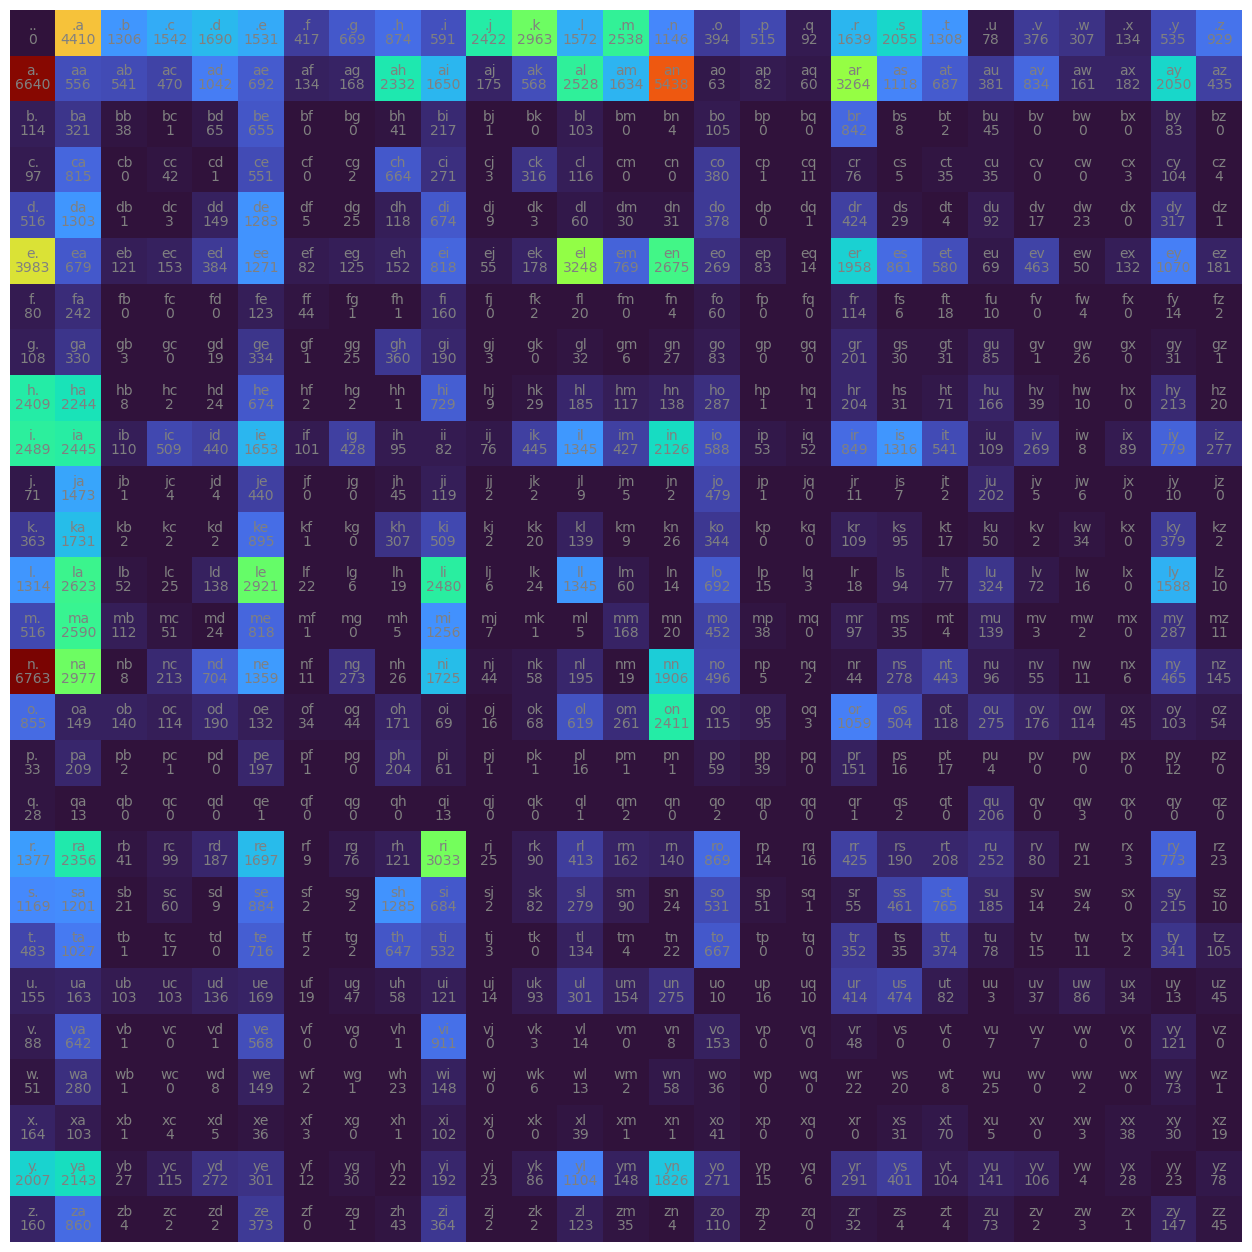

In [18]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='turbo') # turbo, Dark2, seismic, summer, twilight, vanimo, BuPu, Pastel1
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j] # add 2 char 'i' + 'j' = ij
        plt.text(j,i,chstr, ha='center', va='bottom', color='grey')
        plt.text(j,i,N[i,j].item(), ha='center', va='top',color='grey')
plt.axis('off');
# this below shows that combination of bigram (2 char) shows up how many times

In [19]:
N[0, :].shape # meaning, its of the form N[row's index, column's index], so this will display all the columns on row index 0
# we can simply do N[0] too lol

torch.Size([27])

In [20]:
p = N[0].float()
print("before normalization sum of all p is: ", p.sum())
p = p/ p.sum() # this is a normalization technique that tell the probability of that at each occurance, rather than buch of "no of occurance" stuff
print("after normalization sum of all p is: ", p.sum())
p

before normalization sum of all p is:  tensor(32033.)
after normalization sum of all p is:  tensor(1.)


tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [21]:
g = torch.Generator().manual_seed(2147483647) # generator is what pytorch use in the backend as like a "dice" to generate random number when we call .rand
# manual_seed make the same random number each time
p = torch.rand(3, generator=g)
print("without normalizaiton: ", p, p.sum())
p = p/p.sum()
print("with normalizaiton: ", p, p.sum()) # meaning 0.6064 is there is 60.64% of picking the index 0 ... and like this

without normalizaiton:  tensor([0.7081, 0.3542, 0.1054]) tensor(1.1678)
with normalizaiton:  tensor([0.6064, 0.3033, 0.0903]) tensor(1.)


In [22]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)# this returns a 20 element list and at each spin which index it picked at random
# this is like that classic question saying, there are 3 ball red,blue&green, at sampling of 20 times, 
#and replacement = true meaning, when we pick a number, we see it and we place it back
# if we don't set generator = g, it will return different list each time, but we made it deterministic for the sake of this tutorial

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [23]:
# now if we go back to our data
p = N[0].float()
p = p/ p.sum() 
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [24]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [25]:
P= N.float()
#P = P/P.sum()
P.sum(0, keepdim=True) # har row ko seperate seperately add karta hai, 27x27 ka vector tha, so now sum will not be 1 value, but 27 values
# each value will be the sum across that inde's columns
# keepdim will add all those and make the shape as (1,27) => row vector of 2 d imention, not 1 dimention
'''[[sum1 : r11, r12, r13, r14...r127],
 [sum2 : r21, r22, r23, r24...r227],
 [sum3],
 [sum4],
 .
 .
 .
 [sum27]]'''


'[[sum1 : r11, r12, r13, r14...r127],\n [sum2 : r21, r22, r23, r24...r227],\n [sum3],\n [sum4],\n .\n .\n .\n [sum27]]'

In [26]:
#broadcasting rule: 
# 27 27
# 27 1 
# its allowed and the resulting shape is 27 27
P = N.float()
#P1 /= P.sum(1) 
#P = P/P.sum(1, keepdim=True)# this is efficieny issues as p / p.sum will create an  new tensor p then is getting devided by p.sum
# if we use in place operator p /= p.sim this doesn't create any more tensors.
P /= P.sum(1, keepdim=True)
''' 
let me tell me what happens at p1 vs at p, so without keep
'''

' \nlet me tell me what happens at p1 vs at p, so without keep\n'

In [27]:
P[:, 0].sum()

tensor(3.0222)

In [28]:
for i in range(5):
    out=[]
    ix=0
    while True:
        #uniform distribution. ie probability for all is same
        #p = torch.ones(27)/27.0 # this is gonna output terrable terrable otuput like: "mqbzbqlfbkupwcxolcksduicfvfqtylmqinwwzd."
        #bi-gram probabilistic ditribution (sum = 1)
        #p = N[ix].float() # compare to that above, this atleast produces something better, not right or goood, still terrable, but it could have been worst
        #p = p/p.sum()
        p=P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix ==0:
            break
    print(''.join(out))

exze.
momasurailezitynn.
konimittain.
llayn.
ka.


**loss function**

In [29]:
log_likelihood = 0.0
n=0
for w in ['pramitjq']: # we can evaluate the probability for any word we want too
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]): 
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob # log(a*b*c) = log(a) + log(b) + log(c)
        n += 1
        print(f"{ch1}{ch2} : {prob*100:.4f}% : {logprob: .4f}")
        #N[ix1, ix2] += 1

print(f"{log_likelihood=}") # if all the probability are 1 (best fit model) then the log likelyhood will be 0 
# the more bad it peforms the higher negative value it will be, this is ofc opposite of loss function fundamnetals (less number = more accurate)
nll = -log_likelihood
print(f"{nll=}") # now lower this value better the model, before it was, lower the value wost the model
print(f"{nll/n}")


# now when i put in random names in place of the dataset, we get a very intersting observation
# we can see that the probaility of jq coming together is 0% and the loss is in infinite.

.p : 1.6077% : -4.1304
pr : 14.7173% : -1.9161
ra : 18.5512% : -1.6846
am : 4.8222% : -3.0319
mi : 18.9100% : -1.6655
it : 3.0563% : -3.4880
tj : 0.0539% : -7.5265
jq : 0.0000% : -inf
q. : 10.2941% : -2.2736
log_likelihood=tensor(-inf)
nll=tensor(inf)
inf


In [30]:
(1/27.0)*100 # this is the probability of every character pair, if it was a uniform distribution
# we can use this as a benchmark and judge that if anything goes beyong this probability, then its a improving model
# a good model will have all of these near to 100%

3.7037037037037033

***maximum likelyhood estimation***

In [31]:
# GOAL: Maximize likelihood of the data wrt model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average neagtive log likelihood


In [32]:
P = (N+1).float() # we added a count of 1 to everything, this way there will be no combination with 0 probability, the lowest will be 1
# these type of clever tricks are called "model smoothing"
P /= P.sum(1, keepdims=True)

In [33]:
log_likelihood = 0.0
n = 0

for w in words:
#for w in ['andrejq']:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

# now jq has a very small

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


**Using the Bigram approch as Neural Network**

In [34]:
#single char input, and the model will the probability distribution of what the next character could be

In [35]:
xs, ys = [], [] # we will create 2 training set, the input and the target

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2, in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        #print('ix1: ',itos[ix1])
        #print('ix2: ',itos[ix2])
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)
        # what is happening is basically, ix1 and ix2 gives a set of 2 char, like em mm ma and e goes in xs and m goes in ys
        # this is like when we enter 'e' give me the prob distribution of what will be next of e and the answer will be in ys 'w'
        # they are treating a set of bigram 'em' as 'input:output' and input goes in xs (the input traning set) and output goes in ys

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [36]:
xs

tensor([ 0,  5, 13, 13,  1])

In [37]:
ys

tensor([ 5, 13, 13,  1,  0])

In [38]:
# one hot encoding
# big shit name nothing much, it convers each input into its binary level, 
# for ex, we have input as char, so if  i input c it will be encoded as 001000.... 27times, ie, out of 27 char a to z which character is it, and that will be 1


import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float() # we need to define the all the type of classes too, like lets a in a bucket we have 4 unique colors the num class will be 4
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [39]:
xenc.shape

torch.Size([5, 27])

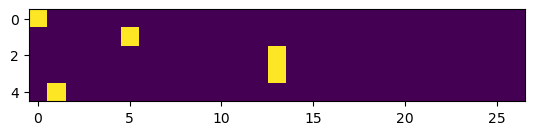

In [40]:
plt.imshow(xenc)

In [41]:
xenc.dtype # this is because the one hot takes the same dtype as the input, and after casting it becomes flaot32
# ideally we want the nn input to be in float

torch.float32

In [42]:
W = torch.randn((27, 27), requires_grad=True) 
# fill random variable in normal distribution -3 to 3 ; 27 1 is the size, ie 27 elements and each element is a list that has 1 element ie itself

# the main point of W is if I see character X, how strongly should I predict each possible next character?, 
# that's why there are 27 input per char out of those 5 char input
# it is of the size, 27 by 27 because 27 input char and 27 output char
# it becomes 5,27 because 5 input char and the possibility distribution of 27 output char against those input char

In [43]:
W[0]

tensor([ 1.0817,  1.2890, -0.4097,  0.2651, -0.6182,  0.2968, -0.2454, -1.4709,
        -0.7351, -0.0761,  0.7763,  1.0529, -1.5448, -1.6588,  1.5470, -1.3076,
        -0.1235, -0.4901, -1.3576,  0.2898, -0.3549,  0.7700,  1.3835, -0.9143,
         0.5644, -0.6521, -0.5009], grad_fn=<SelectBackward0>)

In [44]:
xenc @ W # this does matrix multiplication, (5, 27) x (27, 27) = (5, 27)

tensor([[ 1.0817,  1.2890, -0.4097,  0.2651, -0.6182,  0.2968, -0.2454, -1.4709,
         -0.7351, -0.0761,  0.7763,  1.0529, -1.5448, -1.6588,  1.5470, -1.3076,
         -0.1235, -0.4901, -1.3576,  0.2898, -0.3549,  0.7700,  1.3835, -0.9143,
          0.5644, -0.6521, -0.5009],
        [-0.2420,  0.0130, -0.1895,  1.0442,  0.3624,  0.7398, -0.7396, -1.3535,
         -0.5274,  0.7543,  1.0752, -1.2468, -0.5617,  0.0808, -1.0652, -0.0751,
         -0.9091, -0.4816, -0.2664, -0.3065,  0.8610, -1.3573, -0.6985,  1.7698,
          1.1778, -2.1855,  0.4584],
        [ 1.3434,  0.0126, -0.8334,  0.3594,  0.6830, -0.2130, -0.6198, -0.7877,
         -0.5604,  0.8622, -1.3221, -2.6026,  0.7548, -0.3350,  0.2272, -0.7635,
         -0.5770,  0.6315, -1.6710,  1.4617, -0.1580, -1.4143, -0.8555, -0.2819,
          1.1181, -0.5629, -2.0306],
        [ 1.3434,  0.0126, -0.8334,  0.3594,  0.6830, -0.2130, -0.6198, -0.7877,
         -0.5604,  0.8622, -1.3221, -2.6026,  0.7548, -0.3350,  0.2272, -0.7635

In [45]:
#(xenc @ W).exp() # we are exponentiating these to make it equivalent in vlaue to that heat map "N" thingi that we did, that can be interpret as counts
# all positive number and never below 0 as these are interpreted as "counts"

logits = xenc @ W
counts = logits.exp() # equivalent to N 
probs = counts / counts.sum(1, keepdim=True) # same logic as we did before
probs

tensor([[0.0808, 0.0995, 0.0182, 0.0357, 0.0148, 0.0369, 0.0214, 0.0063, 0.0131,
         0.0254, 0.0596, 0.0786, 0.0058, 0.0052, 0.1287, 0.0074, 0.0242, 0.0168,
         0.0071, 0.0366, 0.0192, 0.0592, 0.1093, 0.0110, 0.0482, 0.0143, 0.0166],
        [0.0224, 0.0289, 0.0236, 0.0811, 0.0410, 0.0598, 0.0136, 0.0074, 0.0168,
         0.0607, 0.0836, 0.0082, 0.0163, 0.0309, 0.0098, 0.0265, 0.0115, 0.0176,
         0.0219, 0.0210, 0.0675, 0.0073, 0.0142, 0.1675, 0.0926, 0.0032, 0.0451],
        [0.1224, 0.0323, 0.0139, 0.0457, 0.0632, 0.0258, 0.0172, 0.0145, 0.0182,
         0.0756, 0.0085, 0.0024, 0.0679, 0.0228, 0.0401, 0.0149, 0.0179, 0.0600,
         0.0060, 0.1377, 0.0273, 0.0078, 0.0136, 0.0241, 0.0977, 0.0182, 0.0042],
        [0.1224, 0.0323, 0.0139, 0.0457, 0.0632, 0.0258, 0.0172, 0.0145, 0.0182,
         0.0756, 0.0085, 0.0024, 0.0679, 0.0228, 0.0401, 0.0149, 0.0179, 0.0600,
         0.0060, 0.1377, 0.0273, 0.0078, 0.0136, 0.0241, 0.0977, 0.0182, 0.0042],
        [0.0071, 0.0212,

In [46]:
probs[0].sum() # now every rows will add up to 1

tensor(1.0000, grad_fn=<SumBackward0>)

In [47]:
probs.shape

torch.Size([5, 27])

In [48]:
probs[3]

tensor([0.1224, 0.0323, 0.0139, 0.0457, 0.0632, 0.0258, 0.0172, 0.0145, 0.0182,
        0.0756, 0.0085, 0.0024, 0.0679, 0.0228, 0.0401, 0.0149, 0.0179, 0.0600,
        0.0060, 0.1377, 0.0273, 0.0078, 0.0136, 0.0241, 0.0977, 0.0182, 0.0042],
       grad_fn=<SelectBackward0>)

In [49]:
# SUMMARY ----------------------------------------->>>>>

In [50]:
xs # input

tensor([ 0,  5, 13, 13,  1])

In [51]:
ys # expected otutput

tensor([ 5, 13, 13,  1,  0])

In [52]:
# randomly initialize 27 nneuron's eirghts. each neuron recieves 27 inputs
g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27,27), generator=g)

In [53]:
# step by step forward pass

# step 1 : encode into one hot encoding
xenc = F.one_hot(xs, num_classes=27).float() # inout to the network: one hot encoding 
# step 2: then multiply with the first layer of the neural net
logits = xenc @ W # predict log counts
# step 3: exponential to get the counts 
counts = logits.exp() # counts, equivalent to N 
# step 4: normalized these counts to ge the probabilities
probs = counts / counts.sum(1, keepdim=True) # probabilistiies for next character
#btw: the last 2 lines here are together called a 'softmax'

# all of these foward pass operations are differentiable, ie we can do backprop with it

In [54]:
probs.shape

torch.Size([5, 27])

In [55]:
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item()  # input character index
    y = ys[i].item()  # label character index
    print('----------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y) # y holds the index btw
    p = probs[i, y]
    print('probability assigned by the net to the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('==========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

----------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0808, 0.0995, 0.0182, 0.0357, 0.0148, 0.0369, 0.0214, 0.0063, 0.0131,
        0.0254, 0.0596, 0.0786, 0.0058, 0.0052, 0.1287, 0.0074, 0.0242, 0.0168,
        0.0071, 0.0366, 0.0192, 0.0592, 0.1093, 0.0110, 0.0482, 0.0143, 0.0166],
       grad_fn=<SelectBackward0>)
label (actual next character): 5
probability assigned by the net to the correct character: 0.03687892109155655
log likelihood: -3.3001151084899902
negative log likelihood: 3.3001151084899902
----------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0224, 0.0289, 0.0236, 0.0811, 0.0410, 0.0598, 0.0136, 0.0074, 0.0168,
        0.0607, 0.0836, 0.0082, 0.0163, 0.0309, 0.0098, 0.0265, 0.0115, 0.0176,
        0.0219, 0.0210, 0.0675, 0.0073, 0.0142, 0.1675, 0.0926, 0.0032, 0.0451],
       grad_fn=<SelectBackward0>)
label (actual next character

In [56]:
# IT ALL COMES DOWN TO HOW WELL WE HAVE OPTIMIZED OUR WEIGHTS, right now its random, but we need to make it proper!
# you can change the seed and expore the loss function

In [57]:
# what we are essentially interesting in are the probabilites of ys

loss = -probs[torch.arange(5), ys].log().mean() # and as you can see its not good, btw arange 5 does 0,1,2,3,4 basically indexes till 4 that are the indexes of the input xs
# probs[0,5], probs[1,13], probs[2,13], probs[3,1], probs[4,0] => .emma.
# you take the log and the means and take the negative and that is the mean negative log likelhood ie the loss!
loss

tensor(3.7880, grad_fn=<NegBackward0>)

**BackProp**

In [58]:
# ------------ !!!! OPTIMIZATION !!! yay -----------------

In [65]:
xs

tensor([ 0,  5, 13, 13,  1])

In [66]:
ys

tensor([ 5, 13, 13,  1,  0])

In [85]:
# randomly initialize 27 nneuron's eirghts. each neuron recieves 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

In [112]:
# step by step forward pass
xenc = F.one_hot(xs, num_classes=27).float() # inout to the network: one hot encoding 
logits = xenc @ W # predict log counts
counts = logits.exp() # counts, equivalent to N 
probs = counts / counts.sum(1, keepdim=True) # probabilistiies for next character
loss = -probs[torch.arange(5), ys].log().mean()
#btw: the last 2 lines here are together called a 'softmax'

In [113]:
# backward pass, set all grad to 0
W.grad = None
loss.backward()

In [114]:
print(loss.item())

3.6891887187957764


In [115]:
W.shape

torch.Size([27, 27])

In [ ]:
W.grad

In [111]:
# update
W.data += -0.1 *W.grad

In [121]:
# now put all these pass on loop and we get gradient decent

In [117]:
# --------------- everything at once ----------------

In [135]:
# create the dataset
xs, ys = [], []
#for w in words[:1]:# here we took only the first word
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples:', num) # and as the first word if of 5 char, the no. of input is also 5

# initialize the network
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples: 228146


In [141]:
# gradient descent
for k in range(10):

    # forward pass

    xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one hot encoding
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean() # this is called regalarizaion, it pushes the W to be 0 (towards less loss)
    # that 0.01 is the regularization strength, we can adust it. STUDY MORE ABOUT IT!!!!!!
    print(loss.item())

    # backward pass
    W.grad = None # set to zero the gradient
    loss.backward()

    # update
    W.data += -50 * W.grad # this loss is same as the bigram approach around ~2.46 but this can be scalabe and more complexity will be done
    # it will only get more complex on the frorward pass, and rest will be same as is   

2.5098888874053955
2.484252691268921
2.483128786087036
2.4830620288848877
2.4830214977264404
2.482987642288208
2.482957363128662
2.48292875289917
2.4829020500183105
2.4828760623931885


In [144]:
# finally, sample from the neural net model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:

        # ----------
        # BEFORE:
        # ----------
        # p = P[ix] # the probability row

        # ----------
        # NOW:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W # predict log-counts
        counts = logits.exp() # counts, equivalent to N
        p = counts / counts.sum(1, keepdims=True) # probabilities for next character
        # ----------

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momakurailezityha.
konimittain.
llayn.
ka.


In [ ]:
cexze.
momasurailezitynn.
konimittain.
llayn.
ka.